# Contact Verification

In this notebook, we will compare the heterogeneous co-simulation of the Controlled Pendulum using `FMUComponent`s and the `MasterPendulum` against a monolithic Modelica reference solution.

We have configured the FEM pendulum and contact as highly stiff in order to a achieve an almost perfectly rigid contact.
This allows us to verify the co-simulation with a multi model component approach against a monolithic Modelica solution.

In [2]:
from pathlib import Path
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

from OMPython import ModelicaSystem
from demos.ControlledPendulum.src.master_pendulum import MasterPendulum
import demos.ControlledPendulum.src.master_pendulum.components.fem.pendulum_config as config
from syssimx import FMUComponent, System, SystemGraphVisualizer, Connection, EventConnection
from syssimx.core.history import SystemHistory

## Configuration of the Master Pendulum

In [4]:
mat_params = config.MaterialParameters()
mat_params.E_pendulum = 2.1e11  # Young's modulus for the pendulum
mat_params.nu_pendulum = 0.3    # Poisson's ratio for the pendulum
mat_params.rho_pendulum = 7800  # Density for the pendulum

fem_parameters = {'mat_params': mat_params}

pendulum = MasterPendulum(name="MasterPendulum", initial_mode="FMU")
pendulum.set_parameters(**{"FEM": fem_parameters})

pendulum.initialize(t0=0.0)

pendulum_mass = pendulum.fem.mass
pendulum_length = pendulum.fem._equivalent_length
pendulum_inertia = pendulum.fem.inertia

print(f"Pendulum Mass: {pendulum_mass:.4f} kg")
print(f"Pendulum Length: {pendulum_length:.4f} m")
print(f"Pendulum Inertia: {pendulum_inertia:.6f} kg*m^2")

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
Pendulum Mass: 10.8430 kg
Pendulum Length: 0.1817 m
Pendulum Inertia: 0.

## Monolithic Modelica Reference Solution

In [6]:
from OMPython import ModelicaSystem
demo_dir_path = Path().cwd() / "demos" / "ControlledPendulum"
pkg_path = demo_dir_path / 'src/modelica/ControlledPendulum/package.mo'
model_name = 'ControlledPendulum.Examples.Contact.Example_Discrete'
ref_system = ModelicaSystem(str(pkg_path), model_name)


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.
Error: Initialization problem is structural singular. Please, check the initial conditions.
Error: Initialization problem is structural singular. Please, check the initial conditions.



In [8]:
ref_system.setParameters(f"pendulum.m={pendulum_mass}")
ref_system.setParameters(f"pendulum.L={pendulum_length}") 
ref_system.setParameters(f"pendulum.J={pendulum_inertia}")

In [10]:
ref_system.buildModel()

Error: Initialization problem is structural singular. Please, check the initial conditions.
Error: Initialization problem is structural singular. Please, check the initial conditions.



In [11]:
ref_system.simulate()

LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.


In [12]:
ref_system.getSolutions()

('$whenCondition5',
 'angle_decoder.nBits',
 'angle_decoder.pot_range',
 'angle_decoder.r_bottom',
 'angle_decoder.r_top',
 'angle_decoder.samplePeriod',
 'angle_decoder.theta',
 'angle_decoder.theta_hold',
 'angle_decoder.theta_max',
 'angle_decoder.theta_min',
 'angle_decoder.v_adc',
 'angle_decoder.v_in',
 'angle_decoder.v_pot',
 'angle_sensor.nBits',
 'angle_sensor.pot_range',
 'angle_sensor.r_bottom',
 'angle_sensor.r_top',
 'angle_sensor.samplePeriod',
 'angle_sensor.theta',
 'angle_sensor.theta_max',
 'angle_sensor.theta_min',
 'angle_sensor.useNoise',
 'angle_sensor.v_adc',
 'angle_sensor.v_hold',
 'angle_sensor.v_out',
 'angle_sensor.v_pot',
 'der(drive.I)',
 'der(pendulum.omega)',
 'der(pendulum.theta)',
 'der(pid.D.x)',
 'der(pid.I.y)',
 'drive.E',
 'drive.I',
 'drive.I_lim',
 'drive.I_max',
 'drive.L_arm',
 'drive.R_arm',
 'drive.U',
 'drive.V_rated',
 'drive.V_supply',
 'drive.dI',
 'drive.eta',
 'drive.gearRatio',
 'drive.k_e',
 'drive.k_n',
 'drive.k_t',
 'drive.n_0',
 '

In [14]:
solution_names = ('time','set_point.theta_ref' ,'pendulum.theta', 'pendulum.contact', 'pid.I_out')
ref_solutions = {name: ref_system.getSolutions(name).flatten() for name in solution_names}

## Load `syssimx` Solutions

In [17]:
system = System(name="ContactVerificationSystem")
system_history = SystemHistory(system_name="ContactVerificationSystem")
system_res_file = Path.cwd() / "demos/ControlledPendulum/artifacts/results/contact_history.csv"
restored_history = system_history.load_csv(system_res_file)

In [24]:
import csv

def load_csv_to_dict(file_path):
    data = {}
    with open(file_path, newline="") as f:
        reader = csv.reader(f)
        headers = next(reader)          # e.g. time,theta,omega,alpha,wall_hit
        units = next(reader)            # e.g. s,rad,rad/s,rad/s^2,

        rows = list(reader)

    # build arrays per column
    cols = list(zip(*rows)) if rows else [[] for _ in headers]

    for name, unit, col in zip(headers, units, cols):
        # convert to float where possible
        values = np.array([float(x) if x not in ("", None) else np.nan for x in col])
        data[name] = {
            "unit": unit if unit != "" else None,
            "values": values
        }

    return data

In [26]:
result_dir = system_res_file.parent

fem_file = result_dir / "fem_history.csv"
fmu_file = result_dir / "fmu_history.csv"
opensim_file = result_dir / "opensim_history.csv"

fem_history = load_csv_to_dict(fem_file)
fmu_history = load_csv_to_dict(fmu_file)
opensim_history = load_csv_to_dict(opensim_file)

In [29]:
t_fem = fem_history['time']['values']
theta_fem = fem_history['theta']['values']

t_fmu = fmu_history['time']['values']
theta_fmu = fmu_history['theta']['values']

t_opensim = opensim_history['time']['values']
theta_opensim = opensim_history['theta']['values']

In [39]:
marker_size = 2
fem_style = {
    "color": "#063ccf",
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 3.5,
} 
opensim_style = {
    "color": "#f8c20f",
    "linestyle": "None",
    "marker": "s",
    "markersize": marker_size,
    "linewidth": 3.5,
}
fmu_style = {
    "color": "#24aa09",
    "linestyle": "None",
    "marker": "^",
    "markersize": marker_size,
    "linewidth": 3.5,
}

## Visualize Results

In [40]:
pendulum_hist = restored_history['MasterPendulum']
theta_hist = pendulum_hist['theta']
t_pendulum = theta_hist['time']
theta_pendulum = theta_hist['values']


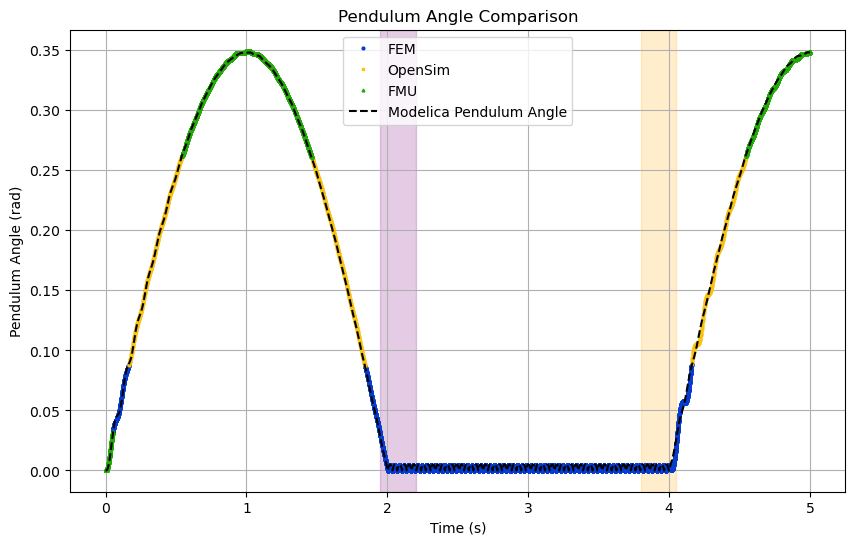

In [41]:
plt.figure(figsize=(10, 6))
plt.plot(t_fem, theta_fem, label='FEM', **fem_style)
plt.plot(t_opensim, theta_opensim, label='OpenSim', **opensim_style)
plt.plot(t_fmu, theta_fmu, label='FMU', **fmu_style)
plt.plot(ref_solutions['time'], ref_solutions['pendulum.theta'],
         label='Modelica Pendulum Angle', linestyle='--', color='black')
plt.axvspan(1.95, 2.2, color="purple", alpha=0.2)
plt.axvspan(3.8, 4.05, color="orange", alpha=0.2)
plt.xlabel('Time (s)')
plt.ylabel('Pendulum Angle (rad)')
plt.title('Pendulum Angle Comparison')
plt.legend()
plt.grid()
plt.show()

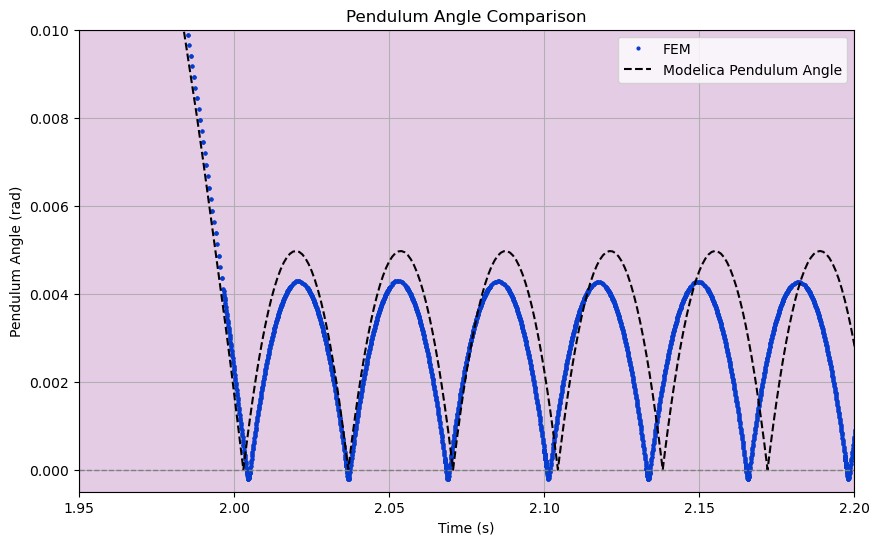

In [42]:
plt.figure(figsize=(10, 6))
plt.plot(t_fem, theta_fem, label='FEM', **fem_style)
plt.plot(ref_solutions['time'], ref_solutions['pendulum.theta'],
         label='Modelica Pendulum Angle', linestyle='--', color='black')
plt.axhline(0.0, color="gray", linestyle="--", linewidth=1)
plt.axvspan(1.95, 2.2, color="purple", alpha=0.2)
plt.xlim(1.95, 2.2)
plt.ylim(-0.0005, 0.01)
plt.xlabel('Time (s)')
plt.ylabel('Pendulum Angle (rad)')
plt.title('Pendulum Angle Comparison')
plt.legend()
plt.grid()
plt.show()

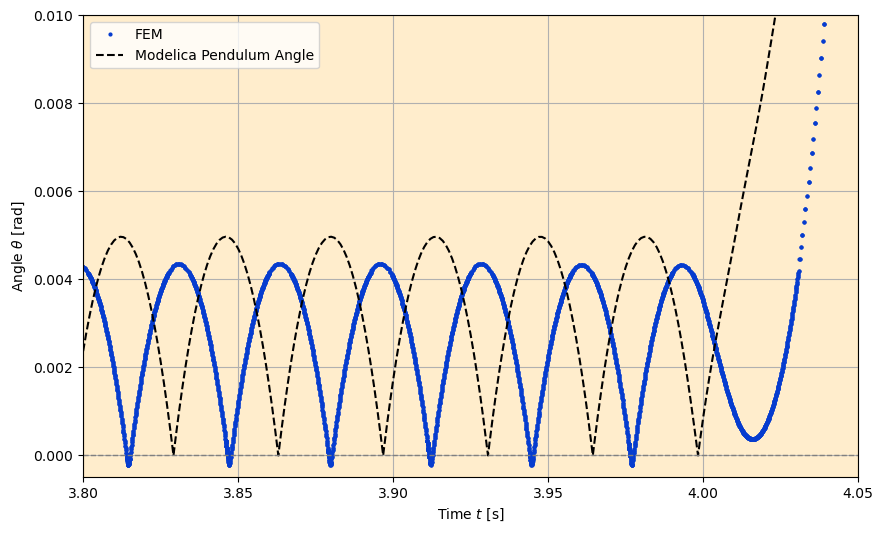

In [43]:
plt.figure(figsize=(10, 6))
plt.plot(t_fem, theta_fem, label='FEM', **fem_style)
plt.plot(ref_solutions['time'], ref_solutions['pendulum.theta'],
         label='Modelica Pendulum Angle', linestyle='--', color='black')
plt.axhline(0.0, color="gray", linestyle="--", linewidth=1)
plt.xlim(3.8, 4.05)
plt.axvspan(3.8, 4.05, color="orange", alpha=0.2)
plt.ylim(-0.0005, 0.01)
plt.xlabel(r"Time $t$ [s]")
plt.ylabel(r"Angle $\theta$ [rad]")
plt.legend()
plt.grid()
plt.show()